In [2]:
from pathlib import Path

import matplotlib

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [9]:
CSV_RELATIVE_PATHS = [
    Path("outputs/white_poc_parsed.csv"),
    Path("../outputs/white_poc_parsed.csv"),
]

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    csv_path = next(
        (
            (candidate_root / relative_path).resolve()
            for relative_path in CSV_RELATIVE_PATHS
            if (candidate_root / relative_path).exists()
        ),
        None,
    )
    if csv_path is not None:
        break
else:
    raise FileNotFoundError("Could not find outputs/white_poc_parsed.csv")

N_METROS = 10
DEFINITION_MONTH_YEAR = "march_2020"
COMPARISON = "white_poc"

METRICS = [
    # "edge_lam_1_angle_1",
    "half_edge_lam_1_angle_1",
    # "edge_lam_1_angle_2",
    # "half_edge_lam_1_angle_2",
    "moran",
    "dissimilarity",
    # "frey",
    # "gini",
]

METRIC_LABELS = {
    # "edge_lam_1_angle_1": "Edge, lambda=1, angle 1",
    "half_edge_lam_1_angle_1": "Half-edge, lambda=1, angle 1",
    # "edge_lam_1_angle_2": "Edge, lambda=1, angle 2",
    # "half_edge_lam_1_angle_2": "Half-edge, lambda=1, angle 2",
    "moran": "Moran",
    "dissimilarity": "Dissimilarity",
    # "frey": "Frey",
    # "gini": "Gini",
}

df = pd.read_csv(csv_path)
required_columns = {
    "definition_month_year",
    "year",
    "cbsa_title",
    "total_population_2020",
    *METRICS,
}
missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

plot_df = df[df["definition_month_year"].eq(DEFINITION_MONTH_YEAR)].copy()
if plot_df.empty:
    raise ValueError(f"No rows found for {DEFINITION_MONTH_YEAR}")

least_pop_metros = (
    plot_df[["cbsa_title", "total_population_2020"]]
    .drop_duplicates()
    .sort_values(["total_population_2020", "cbsa_title"])
    .head(190)
    ["cbsa_title"]
    .tolist()
)

# take a random sample of 10 metros from the least populated metros
least_pop_metros = pd.Series(least_pop_metros).sample(n=N_METROS, random_state=470).tolist()

plot_df = plot_df[plot_df["cbsa_title"].isin(least_pop_metros)].copy()
plot_df["cbsa_title"] = pd.Categorical(
    plot_df["cbsa_title"], categories=least_pop_metros, ordered=True
)
plot_df = plot_df.sort_values(["cbsa_title", "year"])

plot_df[["cbsa_title", "total_population_2020"]].drop_duplicates()

,cbsa_title,total_population_2020
9844,"Terre Haute, IN",185031
9882,"Dalton, GA",142837
157,"Columbia, MO",210864
9934,"Dover, DE",181851
10032,"Santa Fe, NM",154823
3988,"Pocatello, ID",94896
1107,"Jackson, MI",160366
7092,"Hanford-Corcoran, CA",152486
2614,"Elizabethtown-Fort Knox, KY",155572
10021,"Eau Claire, WI",172007


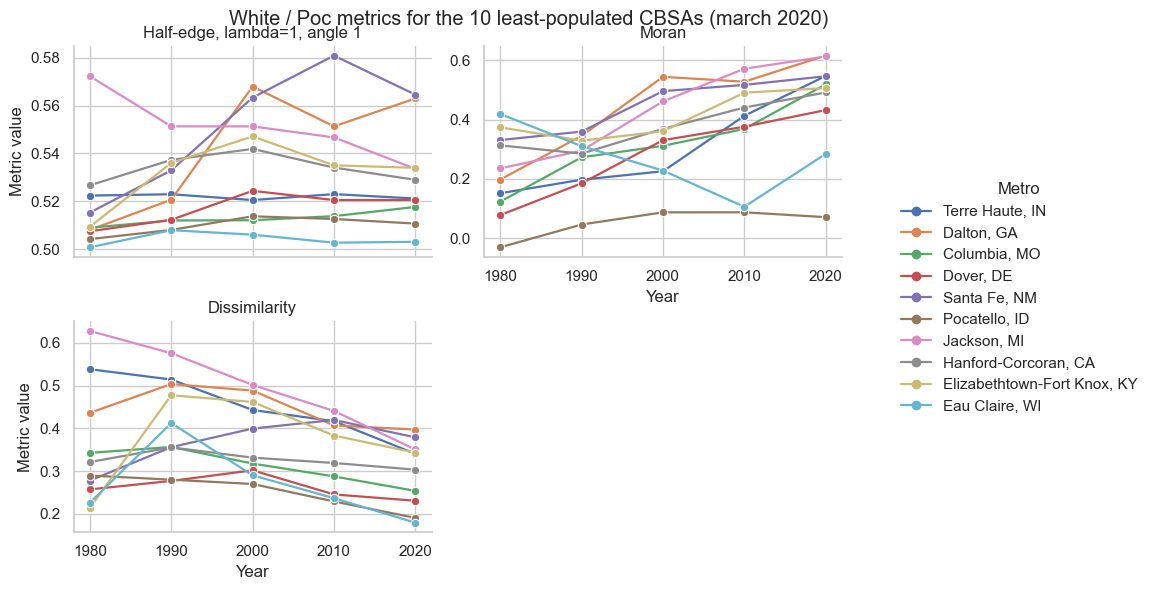

PosixPath('/Users/maria/Documents/capy-bara/outputs/figures/white_poc_march_2020_10_least_pop_metros_metrics.png')

In [10]:
long_df = plot_df.melt(
    id_vars=["year", "cbsa_title"],
    value_vars=METRICS,
    var_name="metric",
    value_name="value",
)
long_df["metric_label"] = pd.Categorical(
    long_df["metric"].map(METRIC_LABELS),
    categories=[METRIC_LABELS[metric] for metric in METRICS],
    ordered=True,
)

grid = sns.relplot(
    data=long_df,
    x="year",
    y="value",
    hue="cbsa_title",
    col="metric_label",
    col_wrap=2,
    kind="line",
    marker="o",
    linewidth=1.6,
    height=3,
    aspect=1.45,
    facet_kws={"sharey": False},
)

grid.set_titles("{col_name}")
grid.set_axis_labels("Year", "Metric value")
for ax in grid.axes.flat:
    ax.set_xticks(sorted(plot_df["year"].unique()))

sns.move_legend(
    grid,
    "center left",
    bbox_to_anchor=(0.82, 0.5),
    title="Metro",
    frameon=False,
)
grid.fig.subplots_adjust(top=0.92, right=0.78)
grid.fig.suptitle(
    f"{COMPARISON.replace('_', ' / ').title()} metrics for "
    f"the {N_METROS} least-populated CBSAs ({DEFINITION_MONTH_YEAR.replace('_', ' ')})"
)

figure_path = (
    csv_path.parent
    / "figures"
    / f"{COMPARISON}_{DEFINITION_MONTH_YEAR}_{N_METROS}_least_pop_metros_metrics.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
grid.fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

figure_path